# **Detección de Emociones Faciales mediante Redes Neuronales Convolucionales e Interpretabilidad con Grad-CAM**

*Trabajo de la asignatura **Deep Learning en Python** — Máster en Ingeniería de Análisis de Datos, Mejora de Procesos y Toma de Decisiones, Universidad Politécnica de Valencia.*

**Autores:** Josselyn Bonilla Albán y Marcos Gibert Robles.


## **Planteamiento del Problema**

**Contexto.** El reconocimiento automático de emociones faciales es una tarea fundamental dentro de la computación afectiva, con aplicaciones en interacción persona-ordenador, monitorización de la salud mental, sistemas de alerta en conducción o tecnologías asistivas para personas con dificultades de interacción social. Automatizar esta tarea reduce la dependencia del juicio humano subjetivo y permite construir sistemas de reconocimiento emocional escalables y en tiempo real.

**Objetivo.** Construir un modelo de aprendizaje profundo capaz de clasificar imágenes faciales en cuatro categorías de emoción —*feliz, triste, neutral* y *sorpresa*— y comparar de forma sistemática dos enfoques: redes preentrenadas en ImageNet (transfer learning con VGG16 y ResNet101) frente a una CNN personalizada entrenada desde cero específicamente para el dominio.

**Preguntas de investigación.** ¿Es capaz una arquitectura basada en CNN de distinguir de forma fiable distintas emociones faciales únicamente a partir de la imagen? ¿Aporta el transfer learning desde ImageNet alguna ventaja cuando las imágenes son pequeñas (48 × 48 píxeles) y en escala de grises? ¿Qué regiones faciales utiliza el modelo para tomar sus decisiones y son coherentes con los rasgos expresivos descritos en la literatura?

**Formulación.** Dado un conjunto de imágenes faciales etiquetadas en cuatro categorías de emoción, se entrenan y evalúan varios modelos de clasificación, se selecciona el de mejor rendimiento y se aplica **Grad-CAM** para obtener explicaciones visuales de sus predicciones.

## **Sobre el dataset**

El conjunto de datos está organizado en tres carpetas (`train`, `validation` y `test`), cada una de ellas con cuatro subcarpetas correspondientes a las clases consideradas:

- **`happy`**: imágenes de personas con expresión facial alegre.
- **`sad`**: imágenes de personas con expresión facial triste o de disgusto.
- **`surprise`**: imágenes de personas con expresión facial de sorpresa o asombro.
- **`neutral`**: imágenes de personas sin una expresión emocional marcada.

Todas las imágenes son fotografías faciales en escala de grises de 48 × 48 píxeles.


## **Montaje de Google Drive**

Este notebook está pensado para ejecutarse en **Google Colab**, de modo que el dataset puede leerse directamente desde el Drive del usuario. La librería `google.colab` solo está disponible en ese entorno y no es instalable en local.


In [1]:
# Mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Importación de librerías**


In [2]:
pip install tensorflow.keras

In [3]:
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

# Importing Deep Learning Libraries

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Input, Dropout, GlobalAveragePooling2D, Flatten, Conv2D, BatchNormalization, Activation, MaxPooling2D, LeakyReLU
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

In [4]:
import warnings
warnings.filterwarnings('ignore')

### **Carga y descompresión de los datos**


**Nota:**
- Antes de ejecutar la siguiente celda hay que subir el dataset comprimido a Google Drive.
- Si se produce algún error al cargar los datos, conviene revisar que la ruta del fichero coincide con la ubicación real en Drive.


In [5]:
# Storing the path of the data file from the Google drive
path = '/content/drive/MyDrive/Facial_emotion_images.zip'

# The data is provided as a zip file so we need to extract the files from the zip file
with zipfile.ZipFile(path, 'r') as zip_ref:
    zip_ref.extractall()

In [6]:
picture_size = 48
folder_path = "Facial_emotion_images/"

## **Visualización de las clases**

Se muestran algunas imágenes de cada categoría con el objetivo de identificar qué rasgos faciales podrían ser más discriminantes para cada emoción y de comprobar visualmente la calidad y la consistencia de las muestras del dataset.


### **Feliz**


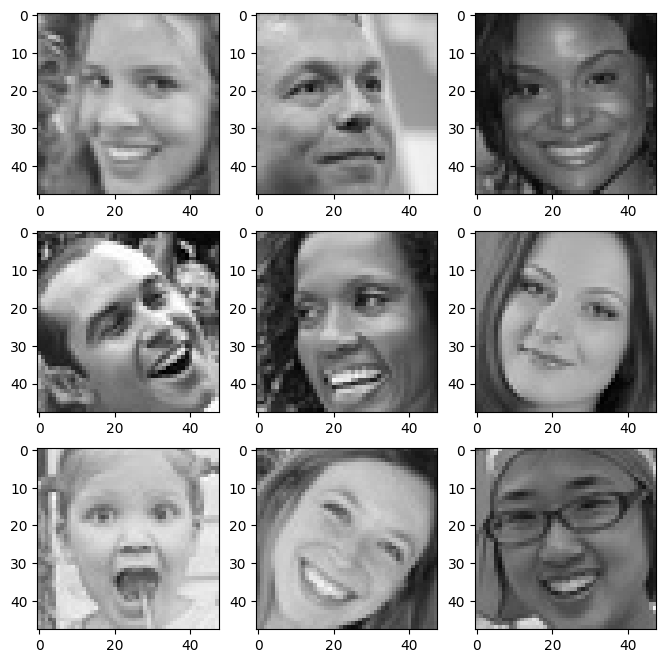

In [ ]:
expression = 'happy'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

### **Triste**


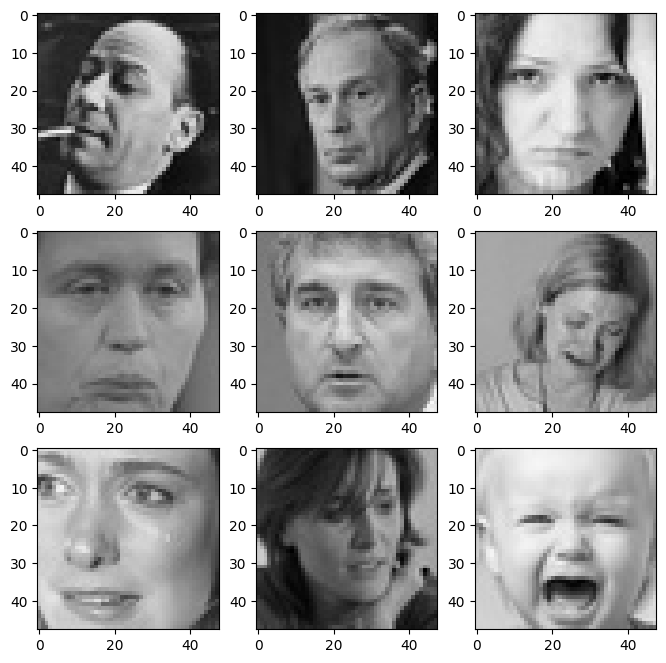

In [ ]:
expression = 'sad'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

### **Neutral**


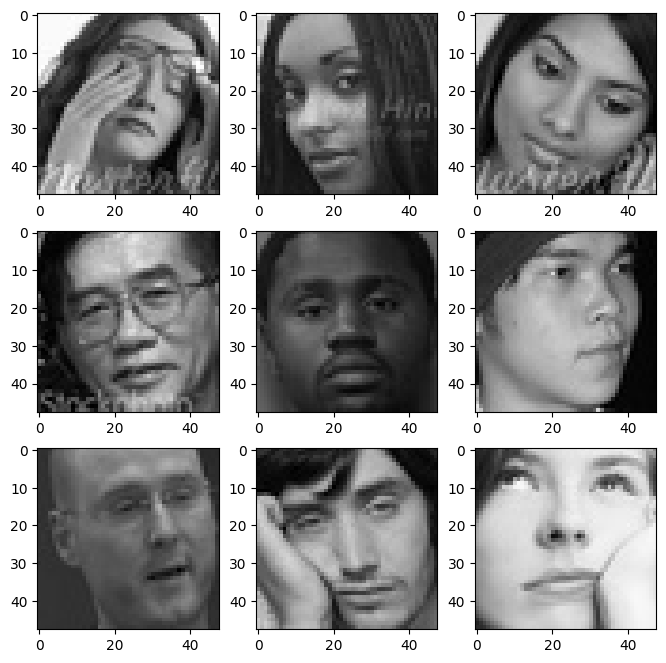

In [ ]:
expression = 'neutral'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

### **Sorpresa**


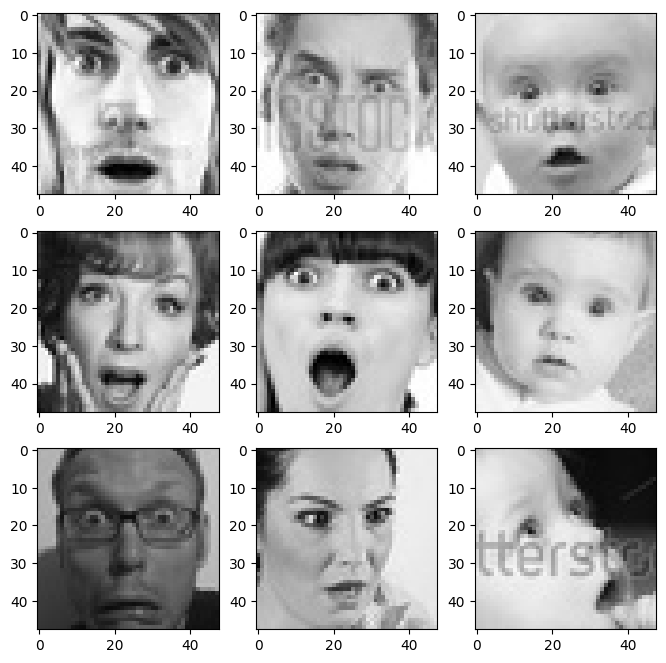

In [ ]:
expression = 'surprise'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

## **Distribución de las clases**

A continuación se analiza el número de imágenes por clase en los tres conjuntos (entrenamiento, validación y test) para detectar posibles desbalanceos que puedan afectar al entrenamiento o a la evaluación posterior.


train set: {'happy': 3976, 'sad': 3982, 'neutral': 3978, 'surprise': 3173}
validation set: {'happy': 1825, 'sad': 1139, 'neutral': 1216, 'surprise': 797}
test set: {'happy': 32, 'sad': 32, 'neutral': 32, 'surprise': 32}


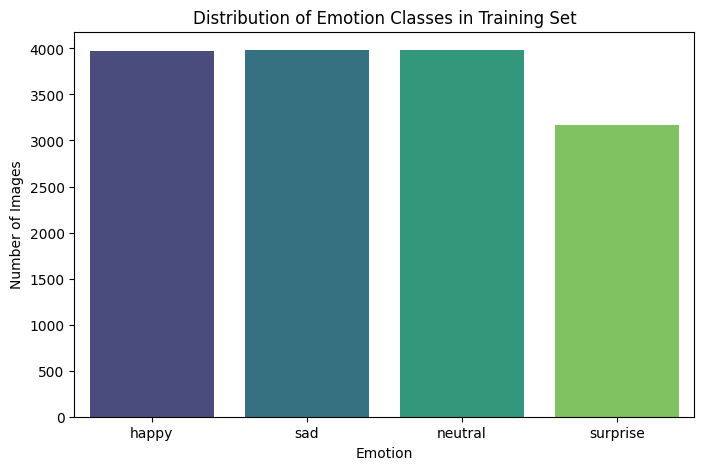

In [7]:

# Checking the distribution of classes in train, validation and test sets
expressions = ['happy', 'sad', 'neutral', 'surprise']

# Count images in each split
for split in ['train', 'validation', 'test']:
    counts = []
    for expr in expressions:
      path = folder_path + split + '/' + expr
      count = len(os.listdir(path))
      counts.append(count)
    print(f"{split} set: {dict(zip(expressions, counts))}")

# Plot distribution for training set
train_counts = [len(os.listdir(folder_path + 'train/' + expr)) for expr in expressions]
plt.figure(figsize=(8, 5))
sns.barplot(x=expressions, y=train_counts, palette='viridis')
plt.title('Distribution of Emotion Classes in Training Set')
plt.xlabel('Emotion')
plt.ylabel('Number of Images')
plt.show()

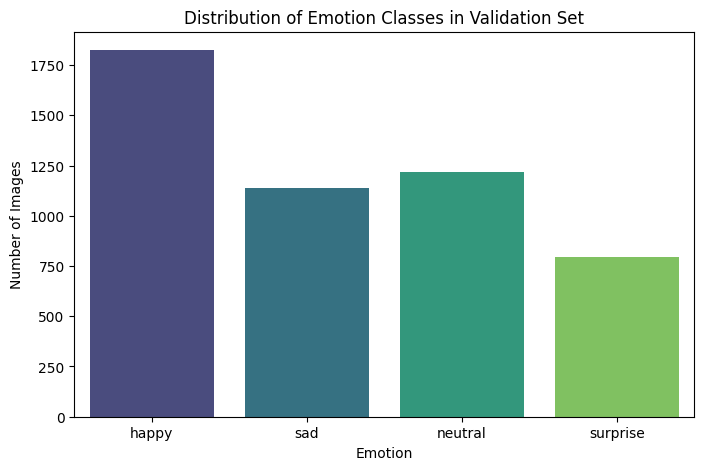

In [ ]:
# Plot distribution for validation set
train_counts = [len(os.listdir(folder_path + 'validation/' + expr)) for expr in expressions]
plt.figure(figsize=(8, 5))
sns.barplot(x=expressions, y=train_counts, palette='viridis')
plt.title('Distribution of Emotion Classes in Validation Set')
plt.xlabel('Emotion')
plt.ylabel('Number of Images')
plt.show()

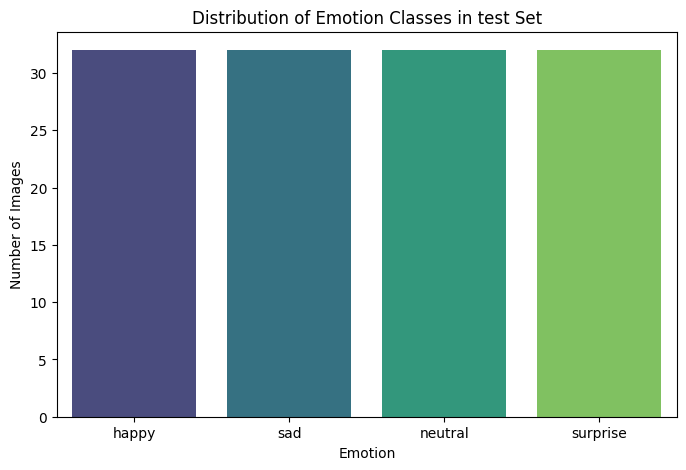

In [ ]:
# Plot distribution for test set
train_counts = [len(os.listdir(folder_path + 'test/' + expr)) for expr in expressions]
plt.figure(figsize=(8, 5))
sns.barplot(x=expressions, y=train_counts, palette='viridis')
plt.title('Distribution of Emotion Classes in test Set')
plt.xlabel('Emotion')
plt.ylabel('Number of Images')
plt.show()

**Observaciones.** En el conjunto de entrenamiento las clases *feliz, triste* y *neutral* están prácticamente equilibradas, con un volumen muy similar de muestras, mientras que la clase *sorpresa* presenta aproximadamente un 20 % menos de imágenes, lo que introduce un ligero desbalanceo. El conjunto de validación reproduce un patrón parecido. El conjunto de test, en cambio, está perfectamente balanceado con el mismo número de imágenes por clase, aunque su tamaño total es reducido (alrededor de un centenar de imágenes). Esto implica que las pequeñas diferencias de *accuracy* entre modelos sobre el test deben interpretarse con cierta cautela, ya que pueden no ser estadísticamente significativas.


## **Generadores de datos**

En esta sección se construyen los *data loaders* que alimentarán a las distintas arquitecturas. Sobre el conjunto de entrenamiento se aplica **aumento de datos online** (rotación aleatoria de ±15°, volteo horizontal y pequeños desplazamientos de anchura/altura de ±10 %) y los píxeles se reescalan al rango [0, 1]. Los conjuntos de validación y test reciben únicamente el reescalado.

Las imágenes originales son en escala de grises, por lo que la CNN personalizada se entrena directamente con un único canal. Para los modelos de transfer learning, en cambio, la entrada se replica en tres canales para adaptarla al formato RGB que esperan las redes preentrenadas en ImageNet.


In [8]:

# Setting up Image Data Generators with grayscale color mode
batch_size = 64

# Using grayscale as it matches the nature of the images (already B&W)
datagen_train = ImageDataGenerator(
rescale=1./255,
rotation_range=15,
width_shift_range=0.1,
height_shift_range=0.1,
horizontal_flip=True)

datagen_val = ImageDataGenerator(rescale=1./255)

train_set = datagen_train.flow_from_directory(
folder_path + "train",
target_size=(picture_size, picture_size),
color_mode='grayscale',
batch_size=batch_size,
class_mode='categorical',
shuffle=True)

validation_set = datagen_val.flow_from_directory(
folder_path + "validation",
target_size=(picture_size, picture_size),
color_mode='grayscale',
batch_size=batch_size,
class_mode='categorical',
shuffle=False)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.


---
## **Transfer Learning**

Como primer enfoque se evalúan dos arquitecturas preentrenadas en ImageNet: **VGG16** y **ResNet101**. En ambos casos, los pesos de la base convolucional se mantienen **congelados** y se añade una cabeza clasificadora personalizada construida con la **API funcional** de Keras (`Flatten → Dense(256) → Dense(128) → Dropout(0.3) → Dense(64) → BatchNormalization → softmax`). La entrada en escala de grises se convierte a RGB replicando el único canal disponible en los tres canales esperados por estas redes.

El objetivo es comprobar hasta qué punto los *features* aprendidos en ImageNet —un dominio de imágenes naturales en color y alta resolución— son útiles para clasificar imágenes faciales de baja resolución en escala de grises.


In [9]:
no_of_classes = 4

# Data loaders en RGB para los modelos de transfer learning
datagen_train_rgb = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen_val_rgb = ImageDataGenerator(rescale=1./255)

train_set_rgb = datagen_train_rgb.flow_from_directory(
    folder_path + "train",
    target_size=(picture_size, picture_size),
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)
validation_set_rgb = datagen_val_rgb.flow_from_directory(
    folder_path + "validation",
    target_size=(picture_size, picture_size),
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)
test_set_rgb = ImageDataGenerator(rescale=1./255).flow_from_directory(
    folder_path + "test",
    target_size=(picture_size, picture_size),
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


### **VGG16**


In [10]:
# Importamos VGG16 con los pesos de ImageNet (estilo de la práctica de clase)
from tensorflow.keras.applications import VGG16, imagenet_utils
from tensorflow.keras import Model

# Cargamos VGG16 sin el top, especificando el input shape de nuestras imágenes
vgg = VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(picture_size, picture_size, 3)
)
vgg.summary()

# Recuperamos la capa de transferencia (último pooling del bloque 5)
transfer_layer = vgg.get_layer('block5_pool')

# Congelamos toda la base para hacer transfer learning puro
vgg.trainable = False


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Construcción del modelo de transfer learning con la API funcional de Keras

# Flatten de la salida de block5_pool
x = Flatten()(transfer_layer.output)

# Cabeza clasificadora: Dense(256) -> Dense(128) -> Dropout(0.3) -> Dense(64) -> BN -> softmax
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)

# Capa final con tantas neuronas como clases y activación softmax
pred = Dense(no_of_classes, activation='softmax')(x)

# Inicializamos el modelo
vggmodel = Model(vgg.input, pred)
vggmodel.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           25

 Total params: 14,887,684 (56.79 MB)

 Trainable params: 172,868 (675.27 KB)

 Non-trainable params: 14,714,816 (56.13 MB)

In [12]:
# Compilamos y entrenamos el modelo VGG16
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

vggmodel.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_vgg = ModelCheckpoint("vgg16_best.keras", monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stop_vgg = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr_vgg = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)

epochs = 20
history_vgg = vggmodel.fit(
    train_set_rgb,
    steps_per_epoch=train_set_rgb.n // train_set_rgb.batch_size,
    epochs=epochs,
    validation_data=validation_set_rgb,
    validation_steps=validation_set_rgb.n // validation_set_rgb.batch_size,
    callbacks=[checkpoint_vgg, early_stop_vgg, reduce_lr_vgg]
)


Epoch 1/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3671 - loss: 1.4093
Epoch 1: val_accuracy improved from None to 0.50162, saving model to vgg16_best.keras

Epoch 1: finished saving model to vgg16_best.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 37s 124ms/step - accuracy: 0.4086 - loss: 1.2974 - val_accuracy: 0.5016 - val_loss: 1.1362 - learning_rate: 0.0010
Epoch 2/20
  1/236 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.4844 - loss: 1.2016
Epoch 2: val_accuracy improved from 0.50162 to 0.50304, saving model to vgg16_best.keras

Epoch 2: finished saving model to vgg16_best.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.4844 - loss: 1.2016 - val_accuracy: 0.5030 - val_loss: 1.1340 - learning_rate: 0.0010
Epoch 3/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4744 - loss: 1.1786
Epoch 3: val_accuracy improved from 0.50304 to 0.51806, saving model to vgg16_best.keras

Epoch 3: finished saving model to vgg16_best.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 37

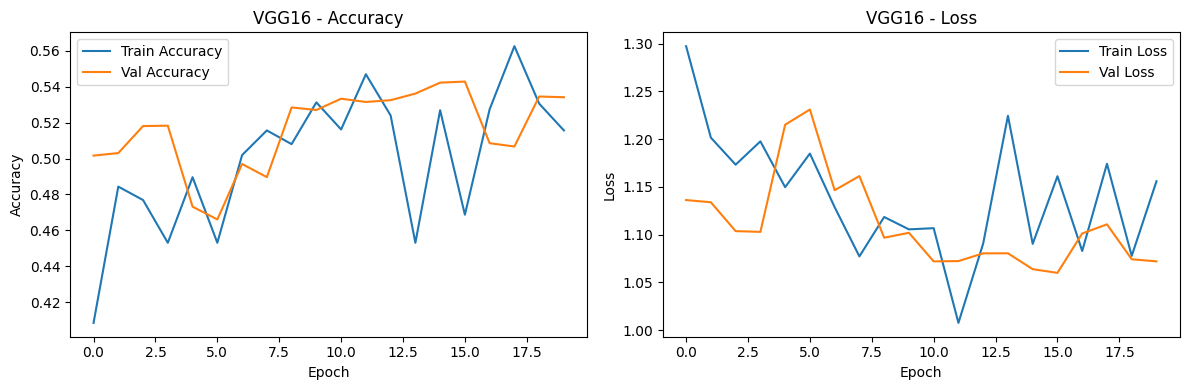

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5000 - loss: 1.0415
VGG16 Test Accuracy: 0.5000, Test Loss: 1.0415


In [13]:
# Evaluación del modelo VGG16 sobre el conjunto de test
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_vgg.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Val Accuracy')
plt.title('VGG16 - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_vgg.history['loss'], label='Train Loss')
plt.plot(history_vgg.history['val_loss'], label='Val Loss')
plt.title('VGG16 - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

test_loss_vgg, test_acc_vgg = vggmodel.evaluate(test_set_rgb)
print(f"VGG16 Test Accuracy: {test_acc_vgg:.4f}, Test Loss: {test_loss_vgg:.4f}")


### **ResNet101**


In [24]:
# Importamos ResNet101 con los pesos de ImageNet (mismo estilo que VGG16)
from tensorflow.keras.applications import ResNet101
from tensorflow.keras import Model

# Cargamos ResNet101 sin el top, con el input shape de nuestras imágenes
Resnet = ResNet101(
    include_top=False,
    weights='imagenet',
    input_shape=(picture_size, picture_size, 3)
)

# Recuperamos la capa de transferencia (último bloque convolucional)
transfer_layer_Resnet = Resnet.get_layer('conv5_block3_out')

# Congelamos toda la base para hacer transfer learning puro
Resnet.trainable = False


In [25]:
# Construcción del modelo de transfer learning con la API funcional de Keras

# Flatten de la salida de conv5_block3_add
x = Flatten()(transfer_layer_Resnet.output)
x = BatchNormalization()(x)

# Cabeza clasificadora: Dense(256) -> Dense(128) -> Dropout(0.3) -> Dense(64) -> BN -> softmax
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)

# Capa final con tantas neuronas como clases y activación softmax
pred = Dense(no_of_classes, activation='softmax')(x)

# Inicializamos el modelo
resnetmodel = Model(Resnet.input, pred)
resnetmodel.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 48, 48, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 54, 54, 3) │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 24, 24,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 24, 24,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 24, 24,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 26, 26,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 12, 12,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 12, 12,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 12, 12,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 12, 12,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 12, 12,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 12, 12,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 12, 12,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 12, 12,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 12, 12,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 12, 12,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 12, 12,    │      1,024 │ conv2_block1_3_c

 Total params: 44,830,020 (171.01 MB)

 Trainable params: 2,155,332 (8.22 MB)

 Non-trainable params: 42,674,688 (162.79 MB)

In [26]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Compilamos y entrenamos el modelo ResNet101
resnetmodel.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_resnet = ModelCheckpoint("resnet_best.keras", monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stop_resnet = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr_resnet = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)

epochs = 15
history_resnet = resnetmodel.fit(
    train_set_rgb,
    steps_per_epoch=train_set_rgb.n // train_set_rgb.batch_size,
    epochs=epochs,
    validation_data=validation_set_rgb,
    validation_steps=validation_set_rgb.n // validation_set_rgb.batch_size,
    callbacks=[checkpoint_resnet, early_stop_resnet, reduce_lr_resnet]
)


Epoch 1/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.2963 - loss: 1.5022
Epoch 1: val_accuracy improved from None to 0.32650, saving model to resnet_best.keras

Epoch 1: finished saving model to resnet_best.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 64s 176ms/step - accuracy: 0.3111 - loss: 1.4229 - val_accuracy: 0.3265 - val_loss: 1.3235 - learning_rate: 0.0010
Epoch 2/15
  1/236 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.3438 - loss: 1.3364
Epoch 2: val_accuracy improved from 0.32650 to 0.33259, saving model to resnet_best.keras

Epoch 2: finished saving model to resnet_best.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.3438 - loss: 1.3364 - val_accuracy: 0.3326 - val_loss: 1.3228 - learning_rate: 0.0010
Epoch 3/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3366 - loss: 1.3521
Epoch 3: val_accuracy improved from 0.33259 to 0.41477, saving model to resnet_best.keras

Epoch 3: finished saving model to resnet_best.keras
236/236 ━━━━━━━━━━━━━━━━━

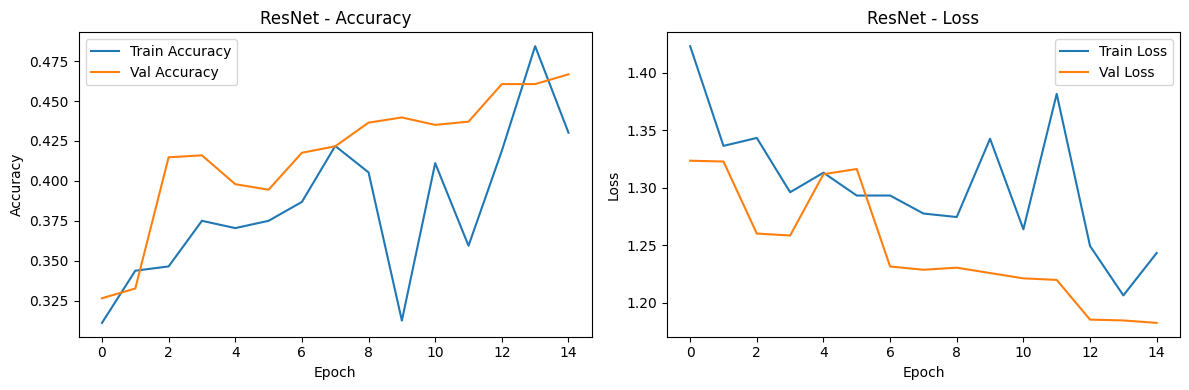

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4531 - loss: 1.1382
ResNet Test Accuracy: 0.4531, Test Loss: 1.1382


In [27]:
# Evaluación del modelo ResNet101 sobre el conjunto de test
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Val Accuracy')
plt.title('ResNet - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['loss'], label='Train Loss')
plt.plot(history_resnet.history['val_loss'], label='Val Loss')
plt.title('ResNet - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

test_loss_resnet, test_acc_resnet = resnetmodel.evaluate(test_set_rgb)
print(f"ResNet Test Accuracy: {test_acc_resnet:.4f}, Test Loss: {test_loss_resnet:.4f}")


**Observaciones.** Ambos modelos de transfer learning presentan un rendimiento muy por debajo de lo esperado: VGG16 se queda en torno al 50 % de *accuracy* y ResNet101 alrededor del 45 %. El motivo principal es el **desajuste de dominio**: los pesos preentrenados en ImageNet están optimizados para imágenes de alta resolución y color, mientras que nuestro dataset consiste en imágenes de 48 × 48 píxeles en escala de grises. La conversión a RGB es meramente formal y no aporta información nueva. Además, el modelo más profundo (ResNet101) rinde peor que VGG16, lo que confirma que los *features* aprendidos sobre objetos genéricos de ImageNet no son directamente transferibles a este dominio.


---
## **CNN personalizada — Modelo final**

Dado el bajo rendimiento del transfer learning, se diseña una **CNN profunda de cinco bloques** entrenada desde cero directamente sobre imágenes en escala de grises de 48 × 48. El número de filtros aumenta progresivamente a lo largo de los bloques (32 → 64 → 128 → 256 → 512), siguiendo la idea de aprender una jerarquía de *features* que va desde bordes y texturas básicas en las primeras capas hasta patrones faciales más complejos en las últimas.

Cada bloque combina convoluciones con `BatchNormalization`, activación `ReLU`, `MaxPooling(2×2)` y `Dropout(0.2)`. La cabeza clasificadora utiliza dos capas densas (1024 y 512 unidades) con `BatchNormalization`, `ReLU` y `Dropout(0.5)`, seguidas de una salida softmax de cuatro clases. El entrenamiento se realiza con el optimizador Adam y los *callbacks* `EarlyStopping` y `ReduceLROnPlateau`.


In [ ]:
# Creating Data Loaders for the Complex CNN (grayscale)
# These are the same as the initial data loaders but we define them here for clarity

datagen_train_complex = ImageDataGenerator(
rescale=1./255,
rotation_range=15,
width_shift_range=0.1,
height_shift_range=0.1,
horizontal_flip=True
)

datagen_val_complex = ImageDataGenerator(rescale=1./255)

train_set = datagen_train_complex.flow_from_directory(
folder_path + "train",
target_size=(picture_size, picture_size),
color_mode='grayscale',
batch_size=batch_size,
class_mode='categorical',
shuffle=True
)

validation_set = datagen_val_complex.flow_from_directory(
folder_path + "validation",
target_size=(picture_size, picture_size),
color_mode='grayscale',
batch_size=batch_size,
class_mode='categorical',
shuffle=False
)

test_set = ImageDataGenerator(rescale=1./255).flow_from_directory(
folder_path + "test",
target_size=(picture_size, picture_size),
color_mode='grayscale',
batch_size=batch_size,
class_mode='categorical',
shuffle=False
)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


In [ ]:

# Building Complex CNN with 5 Convolutional Blocks (grayscale input)
complex_model = Sequential()

# Block 1
complex_model.add(Conv2D(32, (3,3), padding='same', input_shape=(picture_size, picture_size, 1)))
complex_model.add(BatchNormalization())
complex_model.add(Activation('relu'))
complex_model.add(Conv2D(32, (3,3), padding='same'))
complex_model.add(BatchNormalization())
complex_model.add(Activation('relu'))
complex_model.add(MaxPooling2D(pool_size=(2, 2)))
complex_model.add(Dropout(0.2))

# Block 2
complex_model.add(Conv2D(64, (3,3), padding='same'))
complex_model.add(BatchNormalization())
complex_model.add(Activation('relu'))
complex_model.add(Conv2D(64, (3,3), padding='same'))
complex_model.add(BatchNormalization())
complex_model.add(Activation('relu'))
complex_model.add(MaxPooling2D(pool_size=(2, 2)))
complex_model.add(Dropout(0.2))

# Block 3
complex_model.add(Conv2D(128, (3,3), padding='same'))
complex_model.add(BatchNormalization())
complex_model.add(Activation('relu'))
complex_model.add(Conv2D(128, (3,3), padding='same'))
complex_model.add(BatchNormalization())
complex_model.add(Activation('relu'))
complex_model.add(MaxPooling2D(pool_size=(2, 2)))
complex_model.add(Dropout(0.2))

# Block 4
complex_model.add(Conv2D(256, (3,3), padding='same'))
complex_model.add(BatchNormalization())
complex_model.add(Activation('relu'))
complex_model.add(MaxPooling2D(pool_size=(2, 2)))
complex_model.add(Dropout(0.2))

# Block 5
complex_model.add(Conv2D(512, (3,3), padding='same'))
complex_model.add(BatchNormalization())
complex_model.add(Activation('relu'))
complex_model.add(MaxPooling2D(pool_size=(2, 2)))
complex_model.add(Dropout(0.2))

# Fully Connected Layers
complex_model.add(Flatten())
complex_model.add(Dense(1024))
complex_model.add(BatchNormalization())
complex_model.add(Activation('relu'))
complex_model.add(Dropout(0.5))
complex_model.add(Dense(512))
complex_model.add(BatchNormalization())
complex_model.add(Activation('relu'))
complex_model.add(Dropout(0.5))

complex_model.add(Dense(no_of_classes, activation='softmax'))

complex_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 12, 12, 128)    │             

 Total params: 2,824,932 (10.78 MB)

 Trainable params: 2,819,428 (10.76 MB)

 Non-trainable params: 5,504 (21.50 KB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Compile and Train Complex CNN Model
complex_model.compile(
optimizer=Adam(learning_rate=0.001),
loss='categorical_crossentropy',
metrics=['accuracy']
)

checkpoint_complex = ModelCheckpoint("complex_best.keras", monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stop_complex = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr_complex = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)

epochs = 32
history_complex = complex_model.fit(
train_set,
steps_per_epoch=train_set.n // train_set.batch_size,
epochs=epochs,
validation_data=validation_set,
validation_steps=validation_set.n // validation_set.batch_size,
callbacks=[checkpoint_complex, early_stop_complex, reduce_lr_complex]
)




Epoch 1/32
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.2835 - loss: 1.7304
Epoch 1: val_accuracy improved from None to 0.24675, saving model to complex_best.keras

Epoch 1: finished saving model to complex_best.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 56s 122ms/step - accuracy: 0.3025 - loss: 1.5885 - val_accuracy: 0.2468 - val_loss: 1.3970 - learning_rate: 0.0010
Epoch 2/32
  1/236 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.4062 - loss: 1.2185
Epoch 2: val_accuracy did not improve from 0.24675
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4062 - loss: 1.2185 - val_accuracy: 0.2468 - val_loss: 1.3971 - learning_rate: 0.0010
Epoch 3/32
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3717 - loss: 1.3599
Epoch 3: val_accuracy improved from 0.24675 to 0.25406, saving model to complex_best.keras

Epoch 3: finished saving model to complex_best.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - accuracy: 0.3980 - loss: 1.3042 - val_accuracy: 0.2541 - val_loss: 1.4

### **Evaluación sobre el conjunto de test**


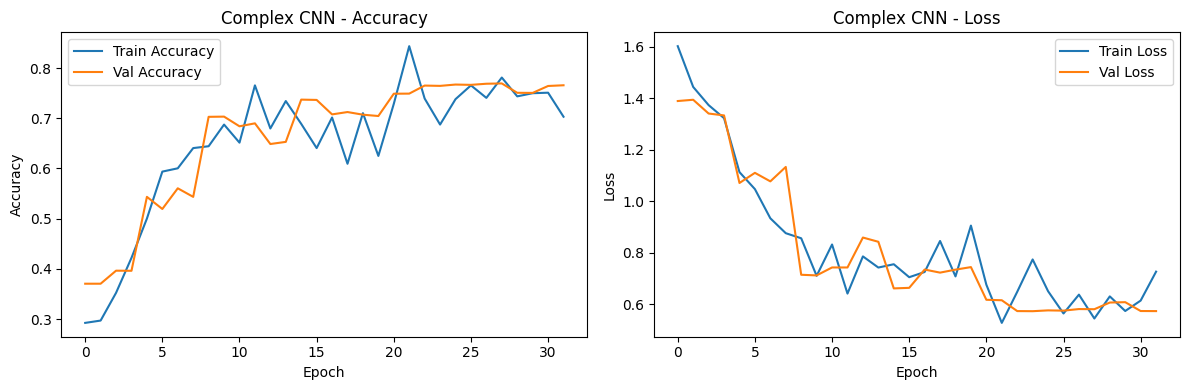

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8516 - loss: 0.4860
Complex CNN Test Accuracy: 0.8516, Test Loss: 0.4860


In [ ]:


# Evaluating Complex CNN Model on Test Set
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_complex.history['accuracy'], label='Train Accuracy')
plt.plot(history_complex.history['val_accuracy'], label='Val Accuracy')
plt.title('Complex CNN - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_complex.history['loss'], label='Train Loss')
plt.plot(history_complex.history['val_loss'], label='Val Loss')
plt.title('Complex CNN - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


test_loss_complex, test_acc_complex = complex_model.evaluate(test_set)
print(f"Complex CNN Test Accuracy: {test_acc_complex:.4f}, Test Loss: {test_loss_complex:.4f}")

### **Matriz de confusión — Modelo final**


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


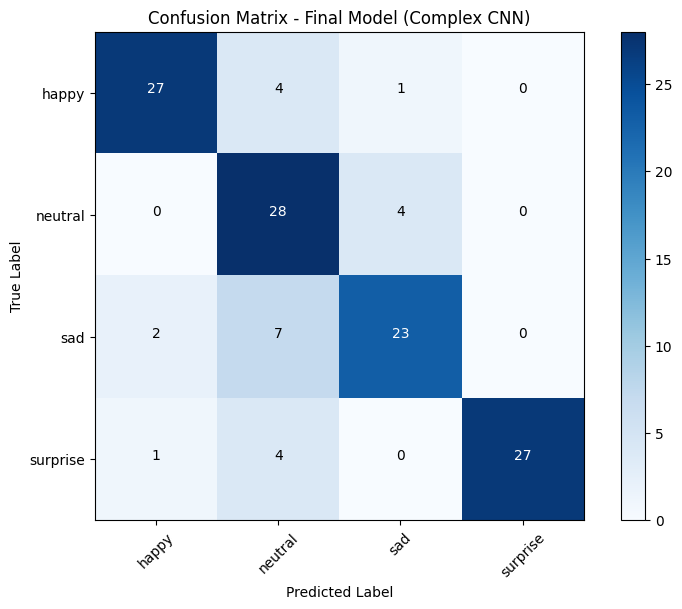


Classification Report:
              precision    recall  f1-score   support

       happy       0.90      0.84      0.87        32
     neutral       0.65      0.88      0.75        32
         sad       0.82      0.72      0.77        32
    surprise       1.00      0.84      0.92        32

    accuracy                           0.82       128
   macro avg       0.84      0.82      0.82       128
weighted avg       0.84      0.82      0.82       128



In [ ]:

# Plotting the Confusion Matrix for the chosen final model (Complex CNN)
from sklearn.metrics import confusion_matrix, classification_report
import itertools

# Get predictions on test set
test_set.reset()
y_pred = complex_model.predict(test_set)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_set.classes
class_labels = list(test_set.class_indices.keys())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Final Model (Complex CNN)')
plt.colorbar()
tick_marks = np.arange(len(class_labels))
plt.xticks(tick_marks, class_labels, rotation=45)
plt.yticks(tick_marks, class_labels)

# Add text annotations
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
  plt.text(j, i, format(cm[i, j], 'd'),
  horizontalalignment="center",
  color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

**Observaciones.** La CNN personalizada obtiene una *accuracy* de en torno al 85 % sobre el conjunto de test y un F1-score macro de 0,82, mejorando de forma muy clara los resultados de los dos modelos de transfer learning. Las clases *feliz* y *sorpresa* son las mejor clasificadas, gracias a que cuentan con rasgos faciales especialmente marcados (sonrisa pronunciada y apertura de ojos/boca, respectivamente). Las clases *triste* y *neutral* presentan algo más de confusión entre sí, lo que es coherente con la sutileza y la similitud visual de sus expresiones. Estos resultados confirman que una arquitectura personalizada, más profunda y adaptada al dominio, supera de forma significativa a los enfoques de transfer learning basados en ImageNet para este tipo de imágenes.


---
## **Grad-CAM — Interpretabilidad del modelo**

Para complementar la evaluación cuantitativa se aplica **Gradient-weighted Class Activation Mapping (Grad-CAM)**, una técnica que genera mapas de calor discriminativos por clase y permite visualizar qué regiones de la imagen tienen más peso en la predicción del modelo. Dado un score de clase $y^c$, se calculan los gradientes respecto a los *feature maps* $A^k$ de la última capa convolucional:

$$\alpha_k^c = \frac{1}{Z} \sum_i \sum_j \frac{\partial y^c}{\partial A^k_{ij}}$$

El mapa de calor se obtiene como una suma ponderada de los *feature maps* a la que se aplica una `ReLU` (para conservar únicamente las activaciones positivas, asociadas a evidencia a favor de la clase):

$$L^c_{\text{Grad-CAM}} = \text{ReLU}\!\left(\sum_k \alpha_k^c A^k\right)$$

Por último, el mapa resultante se redimensiona al tamaño de la imagen original y se superpone sobre ella para facilitar su interpretación visual. En este trabajo, Grad-CAM se aplica a la última capa convolucional del bloque 5, que captura los *features* semánticos de más alto nivel aprendidos por la CNN personalizada.


In [ ]:
import tensorflow as tf
from tensorflow import keras
import cv2


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Calcula el mapa de calor Grad-CAM para una imagen dada.

    Compatibilidad con modelos Sequential de Keras 3: el forward pass
    se realiza capa a capa para capturar el tensor intermedio de la
    última capa Conv2D sin depender del atributo .output de cada capa.

    Parámetros
    ----------
    img_array            : np.ndarray shape (1, H, W, 1), valores en [0, 1]
    model                : modelo Keras entrenado
    last_conv_layer_name : nombre de la última capa Conv2D
    pred_index           : clase objetivo (None = argmax)

    Retorna: heatmap (h, w), pred_index (int), confidence (float)
    """
    layer_names   = [layer.name for layer in model.layers]
    last_conv_idx = layer_names.index(last_conv_layer_name)

    # Paso 1: forward pass hasta la última conv (fuera del tape)
    x = tf.cast(img_array, tf.float32)
    for layer in model.layers[:last_conv_idx + 1]:
        x = layer(x, training=False)
    last_conv_output = x   # tensor de feature maps (1, h, w, C)

    # Paso 2: dentro del tape, observamos last_conv_output y calculamos
    # el resto del forward pass para obtener las predicciones
    with tf.GradientTape() as tape:
        tape.watch(last_conv_output)
        x = last_conv_output
        for layer in model.layers[last_conv_idx + 1:]:
            x = layer(x, training=False)
        predictions = x

        if pred_index is None:
            pred_index = tf.argmax(predictions[0]).numpy()
        class_score = predictions[:, pred_index]

    # Gradientes de la puntuación de clase respecto a los feature maps
    grads = tape.gradient(class_score, last_conv_output)       # (1, h, w, C)

    # Global average pooling de gradientes -> peso de importancia por canal
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))       # (C,)

    # Suma ponderada de feature maps + ReLU + normalizacion
    heatmap = last_conv_output[0] @ pooled_grads[..., tf.newaxis]  # (h, w, 1)
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    confidence = predictions[0][pred_index].numpy()
    return heatmap.numpy(), int(pred_index), float(confidence)


def overlay_heatmap(img_gray, heatmap, alpha=0.45, colormap=cv2.COLORMAP_JET):
    """
    Superpone el mapa de calor Grad-CAM sobre la imagen original en escala de grises.
    Retorna: imagen RGB (H, W, 3) uint8
    """
    img_sq   = np.squeeze(img_gray)
    img_u8   = np.uint8(img_sq * 255)
    img_rgb  = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2RGB)

    # Redimensionar heatmap y aplicar colormap
    hmap_resized = cv2.resize(heatmap, (img_sq.shape[1], img_sq.shape[0]))
    hmap_u8      = np.uint8(255 * hmap_resized)
    hmap_colored = cv2.applyColorMap(hmap_u8, colormap)
    hmap_rgb     = cv2.cvtColor(hmap_colored, cv2.COLOR_BGR2RGB)

    # Mezcla ponderada
    superimposed = (alpha * hmap_rgb + (1 - alpha) * img_rgb).astype(np.uint8)
    return superimposed


In [ ]:
# Detección automática de la última capa Conv2D (objetivo de Grad-CAM)
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, keras.layers.Conv2D):
            return layer.name
    raise ValueError("No se encontró ninguna capa Conv2D en el modelo.")

LAST_CONV_LAYER = find_last_conv_layer(complex_model)
print(f"Capa objetivo de Grad-CAM: '{LAST_CONV_LAYER}'")

Capa objetivo de Grad-CAM: 'conv2d_7'


In [ ]:
# Carga de imágenes aleatorias del test set para las visualizaciones Grad-CAM
import random

EMOTIONS = ['happy', 'sad', 'neutral', 'surprise']
N_PER_CLASS = 8
random.seed(1) # Semilla para reproducibilidad

gradcam_images, gradcam_labels = [], []

for label_idx, emotion in enumerate(EMOTIONS):
    folder = os.path.join(folder_path, 'test', emotion)
    all_files = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Seleccionar 8 archivos aleatorios si hay suficientes, de lo contrario todos
    files = random.sample(all_files, min(len(all_files), N_PER_CLASS))

    for fname in files:
        img = load_img(os.path.join(folder, fname), color_mode='grayscale', target_size=(picture_size, picture_size))
        arr = img_to_array(img) / 255.0   # normalización al rango [0, 1]
        gradcam_images.append(arr)
        gradcam_labels.append(label_idx)

gradcam_images = np.array(gradcam_images, dtype=np.float32)
print(f"Imágenes cargadas: {len(gradcam_images)} | Distribución: {dict(zip(EMOTIONS, [gradcam_labels.count(i) for i in range(len(EMOTIONS))]))}")

Imágenes cargadas: 32 | Distribución: {'happy': 8, 'sad': 8, 'neutral': 8, 'surprise': 8}


### **Vista general — todas las emociones**

Para cada clase se muestran cuatro ejemplos en pares: a la izquierda la imagen original y a la derecha la superposición con el mapa de calor Grad-CAM. El color del borde indica si la predicción es correcta (verde) o errónea (rojo), lo que permite analizar tanto los aciertos como los fallos del modelo desde un punto de vista visual.


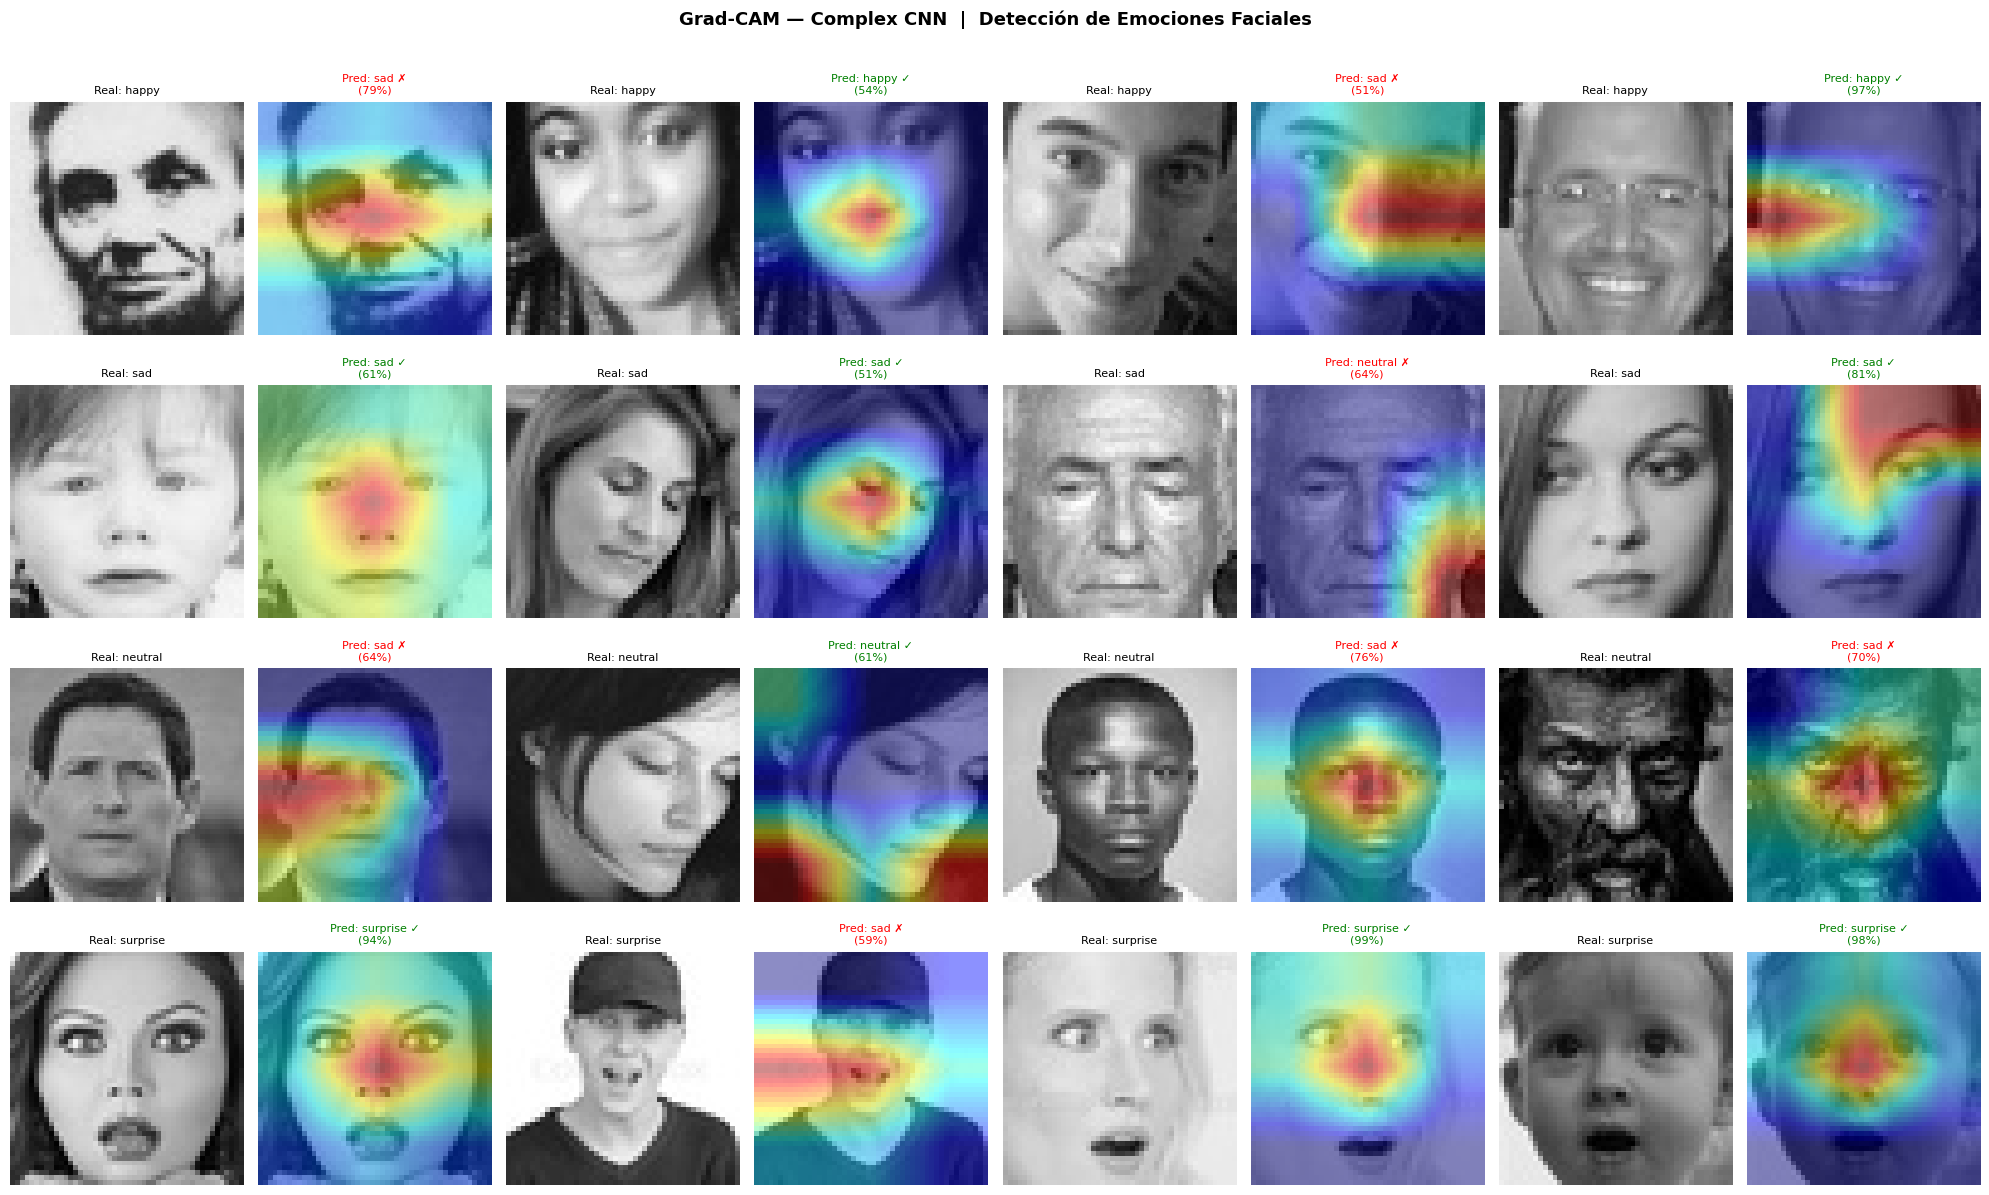

In [ ]:
N_PER_CLASS_PLOT = 4
n_emotions = len(EMOTIONS)

fig, axes = plt.subplots(n_emotions, N_PER_CLASS_PLOT * 2,
                         figsize=(N_PER_CLASS_PLOT * 5, n_emotions * 3))
fig.suptitle("Grad-CAM — Complex CNN  |  Detección de Emociones Faciales",
             fontsize=13, fontweight="bold", y=1.01)

# Agrupar índices por clase
class_indices = {i: [] for i in range(n_emotions)}
for idx, lbl in enumerate(gradcam_labels):
    class_indices[lbl].append(idx)

for row, emotion_idx in enumerate(range(n_emotions)):
    idxs = class_indices[emotion_idx][:N_PER_CLASS_PLOT]
    emotion_name = EMOTIONS[emotion_idx]

    for col_pair, img_idx in enumerate(idxs):
        img       = gradcam_images[img_idx]
        img_batch = np.expand_dims(img, 0)

        heatmap, pred_cls, conf = make_gradcam_heatmap(img_batch, complex_model, LAST_CONV_LAYER)
        overlay = overlay_heatmap(img, heatmap)

        ax_orig = axes[row][col_pair * 2]
        ax_cam  = axes[row][col_pair * 2 + 1]

        ax_orig.imshow(np.squeeze(img), cmap="gray", vmin=0, vmax=1)
        ax_orig.set_title(f"Real: {emotion_name}", fontsize=8)
        ax_orig.axis("off")

        correct = (pred_cls == emotion_idx)
        ax_cam.imshow(overlay)
        ax_cam.set_title(
            f"Pred: {EMOTIONS[pred_cls]} {'✓' if correct else '✗'}\n({conf:.0%})",
            fontsize=8, color="green" if correct else "red"
        )
        ax_cam.axis("off")

    axes[row][0].set_ylabel(emotion_name, fontsize=11, fontweight="bold",
                            rotation=0, labelpad=55, va="center")

plt.tight_layout()
plt.savefig("gradcam_overview_grid.png", dpi=150, bbox_inches="tight")
plt.show()

### **Grad-CAM por clase — ejemplos con mayor confianza**

A continuación, para cada emoción se seleccionan los ejemplos correctamente clasificados con mayor confianza de predicción. Esta vista permite observar con más claridad sobre qué regiones faciales se apoya el modelo cuando está "muy seguro" de su decisión y contrastarlo con los rasgos expresivos descritos en la literatura (sonrisa para *feliz*, apertura de ojos para *sorpresa*, etc.).


In [ ]:
# Carga de imágenes del test set para las visualizaciones Grad-CAM
EMOTIONS   = ['happy', 'sad', 'neutral', 'surprise']
N_PER_CLASS = 32

gradcam_images, gradcam_labels = [], []

for label_idx, emotion in enumerate(EMOTIONS):
    folder = os.path.join(folder_path, 'test', emotion)
    files  = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:N_PER_CLASS]
    for fname in files:
        img = load_img(os.path.join(folder, fname), color_mode='grayscale', target_size=(picture_size, picture_size))
        arr = img_to_array(img) / 255.0   # normalización al rango [0, 1]
        gradcam_images.append(arr)
        gradcam_labels.append(label_idx)

gradcam_images = np.array(gradcam_images, dtype=np.float32)
print(f"Imágenes cargadas: {len(gradcam_images)} | Distribución: {dict(zip(EMOTIONS, [gradcam_labels.count(i) for i in range(4)]))}")

Imágenes cargadas: 128 | Distribución: {'happy': 32, 'sad': 32, 'neutral': 32, 'surprise': 32}


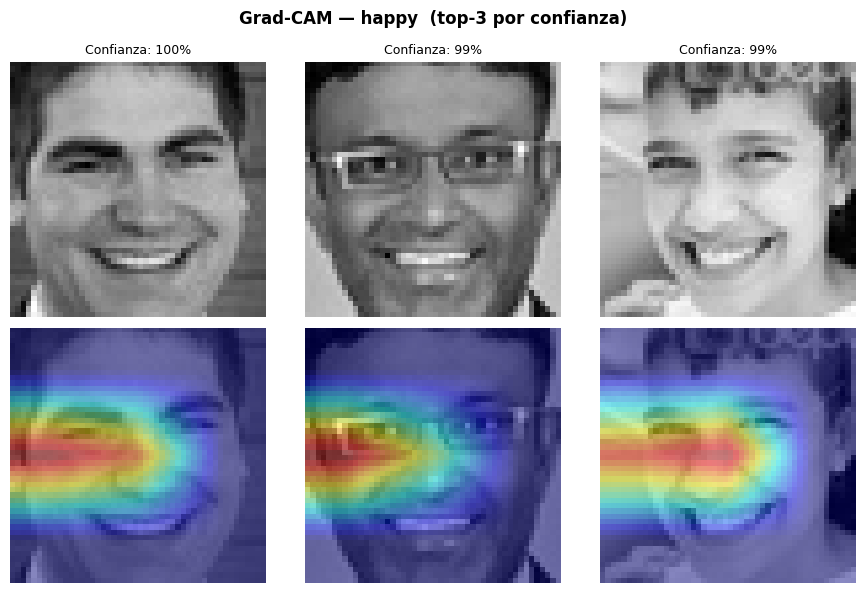

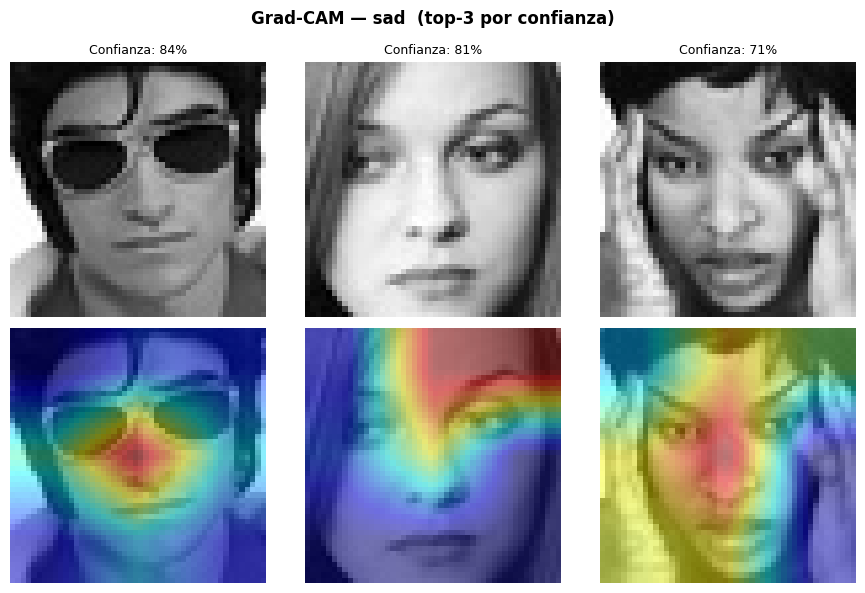

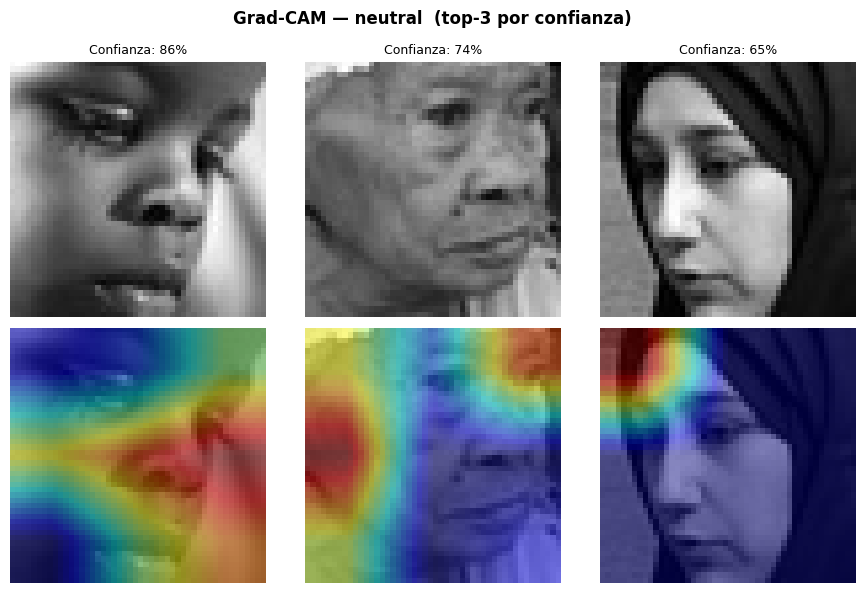

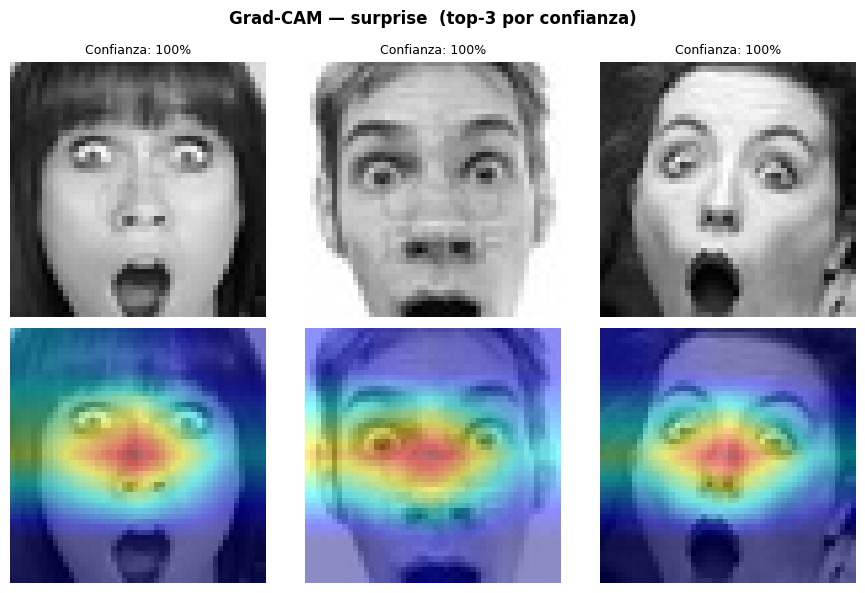

In [ ]:
for emotion_idx, emotion_name in enumerate(EMOTIONS):

    # Recopilar predicciones correctas ordenadas por confianza
    correct_preds = []
    for i, lbl in enumerate(gradcam_labels):
        if lbl != emotion_idx:
            continue
        img_batch = np.expand_dims(gradcam_images[i], 0)
        _, pred_cls, conf = make_gradcam_heatmap(img_batch, complex_model, LAST_CONV_LAYER)
        if pred_cls == emotion_idx:
            correct_preds.append((i, conf))

    correct_preds.sort(key=lambda x: -x[1])
    top_n = correct_preds[:3]

    if not top_n:
        print(f"Sin ejemplos correctamente clasificados para {emotion_name}.")
        continue

    fig, axes = plt.subplots(2, len(top_n), figsize=(len(top_n) * 3, 6))
    fig.suptitle(
        f"Grad-CAM — {emotion_name}  (top-{len(top_n)} por confianza)",
        fontsize=12, fontweight="bold"
    )

    for col, (img_idx, conf) in enumerate(top_n):
        img       = gradcam_images[img_idx]
        img_batch = np.expand_dims(img, 0)
        heatmap, _, confidence = make_gradcam_heatmap(
            img_batch, complex_model, LAST_CONV_LAYER, pred_index=emotion_idx
        )
        overlay = overlay_heatmap(img, heatmap)

        axes[0][col].imshow(np.squeeze(img), cmap="gray")
        axes[0][col].set_title(f"Confianza: {confidence:.0%}", fontsize=9)
        axes[0][col].axis("off")
        if col == 0:
            axes[0][col].set_ylabel("Original", fontsize=9, fontweight="bold")

        axes[1][col].imshow(overlay)
        axes[1][col].axis("off")
        if col == 0:
            axes[1][col].set_ylabel("Grad-CAM", fontsize=9, fontweight="bold")

    plt.tight_layout()
    plt.savefig(f"gradcam_{emotion_name}.png", dpi=150, bbox_inches="tight")
    plt.show()